In [140]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import xgboost as xgb
import src.plot_functions as pf
import data_visualization as dv 

wheel = dv.ColorWheel()
dv.set_plot_style("cashaback_dark.mplstyle")

Successfully changed to cashaback_dark.mplstyle


# Statistical Decision Theory and Optimal Stopping Applied to Credit Cards

# The Idea
I was making a presentation connecting my phd research with credit risk modeling, and one of the examples I came up with during my Aim1 was an optimal stopping problem approach to deciding if you should cancel someone's credit card or not

# The Approach
I think I need to calculate the expected loss/gain of cancelling/not cancelling someone's card. 
This might not be useful... If someone has a positive future expected value, you keep them, obviously. 
The real issue is actually correctly calculating all the probabilities.

# Anticipated Problems
1. This problem is also "infinite" time. 
   - How far out do we simulate? 
   - 

I basically want a time series of someone's expected gain over time! Then we want to stop at the point that minimizes future losses.
- Is there a weird situation that you might stop someone early? I guess you can cancel at any time, so might as stop them right when they cross over into negative expected loss.

- So this is like forecasting, but I need a dynamic equation that models EG/EL as a function of time, with modifying parameters determined by the features of the model.

# Types of Customers
1. Transactors
  - They pay off their cards in full every month, accruing no interest
  - low risk, low profits
  - Easy decision: keep them

2. Debtors
  - They have debt on their credit card that accrues interest, but they pay it off
  - Medium risk, medium profits
  - Hard decision: should we cancel now? or wait it out? 
  - When do they transition to the Defaulters category? 

3. Defaulters
  - They haven't paid off, and no signs point to them paying it off soon
  - High risk, low profits
  - Easy decision: cancel their card
  

# Approach
1. Let's take the GiveMeSomeCredit data, and calculate the expected gain/loss of having them as a customer
2. I don't know how to train these data...

# Load Data

In [141]:
df = pl.read_excel("data/default_of_credit_card_clients.xls", read_options={'header_row': 1})
rename_col_dict = {
    "PAY_0": "PAY_STATUS_SEP", 
    "PAY_2": "PAY_STATUS_AUG",
    "PAY_3": "PAY_STATUS_JUL",
    "PAY_4": "PAY_STATUS_JUN",
    "PAY_5": "PAY_STATUS_MAY",
    "PAY_6": "PAY_STATUS_APR",
    "BILL_AMT1": "BILL_AMT_SEP",
    "BILL_AMT2": "BILL_AMT_AUG",
    "BILL_AMT3": "BILL_AMT_JUL",
    "BILL_AMT4": "BILL_AMT_JUN",
    "BILL_AMT5": "BILL_AMT_MAY",
    "BILL_AMT6": "BILL_AMT_APR",
    "PAY_AMT1": "PAY_AMT_SEP",
    "PAY_AMT2": "PAY_AMT_AUG",
    "PAY_AMT3": "PAY_AMT_JUL",
    "PAY_AMT4": "PAY_AMT_JUN",
    "PAY_AMT5": "PAY_AMT_MAY",
    "PAY_AMT6": "PAY_AMT_APR",
    "default payment next month": "DEFAULT_PAYMENT_NEXT_MONTH"
}
months = [
    "SEP",
    "AUG",
    "JUL",
    "JUN",
    "MAY",
    "APR",
]
df = df.rename(rename_col_dict)
rename_col_dict.pop('default payment next month')
df.head()

ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_STATUS_SEP,PAY_STATUS_AUG,PAY_STATUS_JUL,PAY_STATUS_JUN,PAY_STATUS_MAY,PAY_STATUS_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT_PAYMENT_NEXT_MONTH
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


# Explore Data

In [142]:
df.describe()

statistic,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_STATUS_SEP,PAY_STATUS_AUG,PAY_STATUS_JUL,PAY_STATUS_JUN,PAY_STATUS_MAY,PAY_STATUS_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT_PAYMENT_NEXT_MONTH
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",15000.5,167484.322667,1.603733,1.853133,1.551867,35.4855,-0.0167,-0.133767,-0.1662,-0.220667,-0.2662,-0.2911,51223.3309,49179.075167,47013.1548,43262.948967,40311.400967,38871.7604,5663.5805,5921.1635,5225.6815,4826.076867,4799.387633,5215.502567,0.2212
"""std""",8660.398374,129747.661567,0.489129,0.790349,0.52197,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,69349.387427,64332.856134,60797.15577,59554.107537,16563.280354,23040.870402,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
"""min""",1.0,10000.0,1.0,0.0,0.0,21.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-165580.0,-69777.0,-157264.0,-170000.0,-81334.0,-339603.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",7501.0,50000.0,1.0,1.0,1.0,28.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,3559.0,2985.0,2667.0,2327.0,1763.0,1256.0,1000.0,833.0,390.0,296.0,253.0,118.0,0.0
"""50%""",15001.0,140000.0,2.0,2.0,2.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,22382.0,21203.0,20089.0,19052.0,18105.0,17074.0,2100.0,2009.0,1800.0,1500.0,1500.0,1500.0,0.0
"""75%""",22500.0,240000.0,2.0,2.0,2.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,67090.0,64004.0,60164.0,54503.0,50185.0,49196.0,5006.0,5000.0,4505.0,4013.0,4031.0,4000.0,0.0
"""max""",30000.0,1e6,2.0,6.0,3.0,79.0,8.0,8.0,8.0,8.0,8.0,8.0,964511.0,983931.0,1.664089e6,891586.0,927171.0,961664.0,873552.0,1.684259e6,896040.0,621000.0,426529.0,528666.0,1.0


# Clean Data

# XG Boost to get prob_default

In [143]:
train,test = train_test_split(df)
X_train = train.drop("DEFAULT_PAYMENT_NEXT_MONTH")
X_test = test.drop("DEFAULT_PAYMENT_NEXT_MONTH")
y_train = train["DEFAULT_PAYMENT_NEXT_MONTH"]
y_test = test["DEFAULT_PAYMENT_NEXT_MONTH"]
FEATURES = list(X_train.columns)[1:]
print(f"Num defaults {train['DEFAULT_PAYMENT_NEXT_MONTH'].sum()}")
print(f"Num non-defaults {len(train) - train['DEFAULT_PAYMENT_NEXT_MONTH'].sum()}")


Num defaults 4915
Num non-defaults 17585


In [144]:
y_train == 0

DEFAULT_PAYMENT_NEXT_MONTH
bool
true
true
false
true
true
…
true
false
true


In [145]:
# Create xgb regression model
# n_estimators is the number of trees, more is more complex, but can lead to overfitting
# scale_pos_weight is for unbalanced data sets, negative meaning minority class
majority_instances = np.sum(y_train.to_pandas() == 0)
minority_instances = np.sum(y_train.to_pandas() == 1)
scale_pos_weight = majority_instances / minority_instances
clf = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=2,
    # n_features=2,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
)

_ = clf.fit(
    X_train[FEATURES],
    y_train,
    eval_set=[(X_train[FEATURES], y_train), (X_test[FEATURES], y_test)],
    verbose=100,
)


[0]	validation_0-auc:0.73055	validation_1-auc:0.73671
[100]	validation_0-auc:0.78107	validation_1-auc:0.77747
[200]	validation_0-auc:0.79071	validation_1-auc:0.78205
[300]	validation_0-auc:0.79572	validation_1-auc:0.78397
[400]	validation_0-auc:0.79976	validation_1-auc:0.78472
[500]	validation_0-auc:0.80304	validation_1-auc:0.78509
[600]	validation_0-auc:0.80605	validation_1-auc:0.78523
[700]	validation_0-auc:0.80867	validation_1-auc:0.78540
[800]	validation_0-auc:0.81120	validation_1-auc:0.78571
[900]	validation_0-auc:0.81365	validation_1-auc:0.78594
[999]	validation_0-auc:0.81589	validation_1-auc:0.78594


## Feature importance, auc

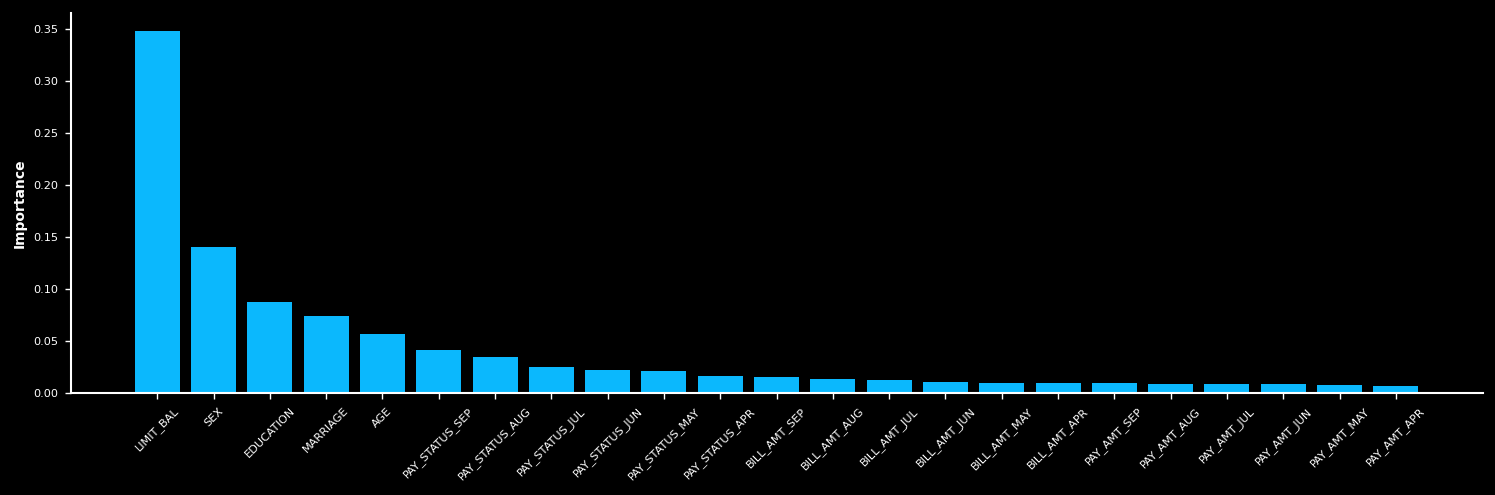

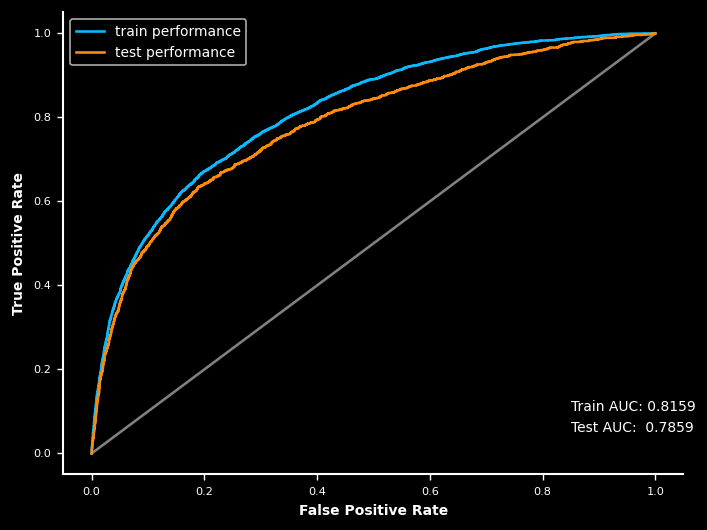

In [146]:
fig, ax = plt.subplots(figsize=(12, 4))
xlocs = np.arange(0, len(FEATURES))
ax.bar(xlocs, -np.sort(-clf.feature_importances_))
ax.set_xticks(xlocs, labels=FEATURES, rotation=45)
ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()

# Calculate roc auc
xg_train_preds = clf.predict_proba(X_train[FEATURES])[:, 1]
xg_test_preds = clf.predict_proba(X_test[FEATURES])[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, xg_train_preds)
fpr_test, tpr_test, _ = roc_curve(y_test, xg_test_preds)
train_auc = roc_auc_score(y_train, xg_train_preds)
test_auc = roc_auc_score(y_test, xg_test_preds)

# Plot roc auc
fig, ax = plt.subplots()
pf.plot_roc(ax, fpr_train, tpr_train, fpr_test, tpr_test, train_auc, test_auc)
plt.show()

# Organize Data With Predictions

## Make predictions on prob_default

In [147]:
final_xg_preds = clf.predict_proba(df[FEATURES])[:, 1]


In [148]:
# Cols = [month, pay_status, bill_amt, pay_amt]
money_df = df.clone()
value_cols = list(rename_col_dict.values()) 
temp_df = df.unpivot(
    on=value_cols,
    index='ID'
)
long_prob_default = np.tile(final_xg_preds, 6)

money_df = pl.DataFrame().with_columns(
    idx = temp_df.filter(pl.col("variable").str.contains("PAY_STATUS"))['ID'],
    month = temp_df.filter(pl.col("variable").str.contains("PAY_STATUS"))['variable'].str.tail(3),
    pay_status = temp_df.filter(pl.col("variable").str.contains("PAY_STATUS"))['value'],
    bill_amt = temp_df.filter(pl.col("variable").str.contains("BILL_AMT"))['value'],
    pay_amt = temp_df.filter(pl.col("variable").str.contains("PAY_AMT"))['value'],
    prob_default = long_prob_default
    
).sort(pl.col("idx"))

# Major Assumption for simplification: Everyone starts the month with no debt, and they pay on the next month
# I don't know how much they started with in this dataset, so to properly calculate the interest accrued, I'm doing this 
money_df = money_df.with_columns(
    pay_amt = pl.when(pl.col("month")=="APR").then(0).otherwise(pl.col("pay_amt"))
)
# Add debt column
money_df = money_df.with_columns(
    unpaid_amt = pl.col("bill_amt").shift(-1).sub(pl.col("pay_amt")).over(pl.col("idx"))
)
# Sometimes people have negative unpaid amts, going to just zero that out for now
money_df = money_df.with_columns(
    unpaid_amt = pl.when(pl.col("unpaid_amt")<0).then(0).otherwise(pl.col("unpaid_amt"))
)


money_df.filter(pl.col("idx")==12)

idx,month,pay_status,bill_amt,pay_amt,prob_default,unpaid_amt
i64,str,i64,i64,i64,f32,i64
12,"""SEP""",-1,12261,21818,0.260105,0
12,"""AUG""",-1,21670,9966,0.260105,0
12,"""JUL""",-1,9966,8583,0.260105,0
12,"""JUN""",-1,8517,22301,0.260105,0
12,"""MAY""",-1,22287,0,0.260105,13668
12,"""APR""",2,13668,0,0.260105,null


## Calculate Expected Profit and Loss on next month
$EP = \alpha * E_{bill} + (\beta * unpaid) * (1 - P(Default)) $

$E_{bill} := $ Expected bill next month (avg of past 6 months)

$  \alpha :=$ transaction fee

$  \beta := $ interest rate 

$EL = P(Default) * EAD * LGD $

$ EG = EP - EL $

- I'm simplifying for the time being. E[L] = PD * LGD * EAD, usually. I'm assuming LGD is 100% (meaning you won't recover any losses through collateral)

In [149]:
money_df.filter(pl.col("idx")==1)

idx,month,pay_status,bill_amt,pay_amt,prob_default,unpaid_amt
i64,str,i64,i64,i64,f32,i64
1,"""SEP""",2,3913,0,0.885162,3102
1,"""AUG""",2,3102,689,0.885162,0
1,"""JUL""",-1,689,0,0.885162,0
1,"""JUN""",-1,0,0,0.885162,0
1,"""MAY""",-2,0,0,0.885162,0
1,"""APR""",-2,0,0,0.885162,null


In [150]:
TXN_FEE = 0.02
INT_RATE = 0.2
#
# transaction profits and interest accrued
# I'm assuming that the interest accrued goes into the next bill, so I'm not adding it in myself
# I'm also not calculating interest with the daily rate, so this is not perfectly accurate
money_df = money_df.with_columns(
    interest_accrued = pl.col("unpaid_amt").mul(INT_RATE),
    txn_profits = pl.col("bill_amt").mul(TXN_FEE),
)
money_df = money_df.with_columns(
    expected_profits = pl.col("interest_accrued").mul(1 - pl.col("prob_default")).add(pl.col("txn_profits")),
    expected_loss = pl.col("unpaid_amt").mul(pl.col("prob_default"))
)
money_df = money_df.with_columns(
    expected_gain = pl.col("expected_profits").sub(pl.col("expected_loss"))
)
money_df

idx,month,pay_status,bill_amt,pay_amt,prob_default,unpaid_amt,interest_accrued,txn_profits,expected_profits,expected_loss,expected_gain
i64,str,i64,i64,i64,f32,i64,f64,f64,f64,f64,f64
1,"""SEP""",2,3913,0,0.885162,3102,620.4,78.26,149.50535,2745.773251,-2596.267901
1,"""AUG""",2,3102,689,0.885162,0,0.0,62.04,62.04,0.0,62.04
1,"""JUL""",-1,689,0,0.885162,0,0.0,13.78,13.78,0.0,13.78
1,"""JUN""",-1,0,0,0.885162,0,0.0,0.0,0.0,0.0,0.0
1,"""MAY""",-2,0,0,0.885162,0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…
30000,"""AUG""",0,48905,1800,0.432984,47964,9592.8,978.1,6417.374568,20767.628588,-14350.254019
30000,"""JUL""",0,49764,1430,0.432984,35105,7021.0,995.28,4976.301886,15199.891618,-10223.589732
30000,"""JUN""",0,36535,1000,0.432984,31428,6285.6,730.7,4294.738052,13607.810676,-9313.072624


In [156]:
money_df.filter(pl.col("expected_profits")<0)

idx,month,pay_status,bill_amt,pay_amt,prob_default,unpaid_amt,interest_accrued,txn_profits,expected_profits,expected_loss,expected_gain
i64,str,i64,i64,i64,f32,i64,f64,f64,f64,f64,f64
8,"""MAY""",0,-159,1687,0.309444,0,0.0,-3.18,-3.18,0.0,-3.18
27,"""SEP""",1,-109,0,0.6589,0,0.0,-2.18,-2.18,0.0,-2.18
27,"""AUG""",-2,-425,1000,0.6589,0,0.0,-8.5,-8.5,0.0,-8.5
27,"""JUN""",-1,-57,500,0.6589,0,0.0,-1.14,-1.14,0.0,-1.14
36,"""AUG""",-1,-131,396,0.330431,0,0.0,-2.62,-2.62,0.0,-2.62
…,…,…,…,…,…,…,…,…,…,…,…
29923,"""JUN""",-2,-18,0,0.516611,0,0.0,-0.36,-0.36,0.0,-0.36
29923,"""MAY""",-2,-18,0,0.516611,0,0.0,-0.36,-0.36,0.0,-0.36
29963,"""SEP""",1,-264,528,0.520145,0,0.0,-5.28,-5.28,0.0,-5.28


In [157]:
money_df.filter(pl.col("idx")==8)

idx,month,pay_status,bill_amt,pay_amt,prob_default,unpaid_amt,interest_accrued,txn_profits,expected_profits,expected_loss,expected_gain
i64,str,i64,i64,i64,f32,i64,f64,f64,f64,f64,f64
8,"""SEP""",0,11876,380,0.309444,0,0.0,237.52,237.52,0.0,237.52
8,"""AUG""",-1,380,601,0.309444,0,0.0,7.6,7.6,0.0,7.6
8,"""JUL""",-1,601,0,0.309444,221,44.2,12.02,42.542598,68.387014,-25.844416
8,"""JUN""",0,221,581,0.309444,0,0.0,4.42,4.42,0.0,4.42
8,"""MAY""",0,-159,1687,0.309444,0,0.0,-3.18,-3.18,0.0,-3.18
8,"""APR""",-1,567,0,0.309444,null,null,11.34,null,null,null


## Boxplots with individual data over time

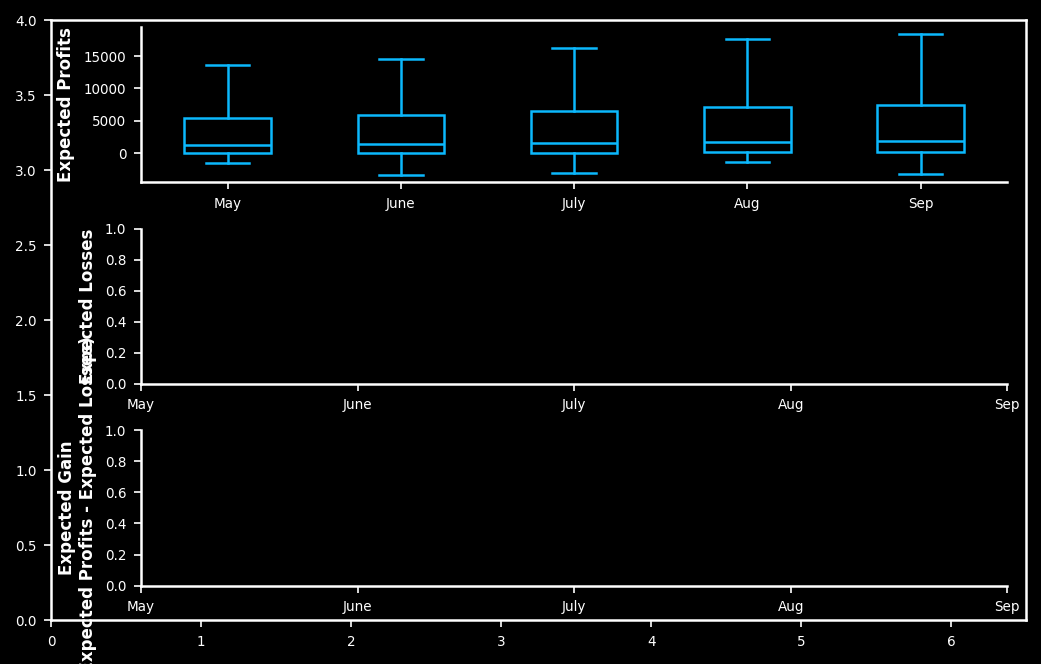

In [151]:
ep_each_month_df = (money_df
    .group_by(pl.col("month"), maintain_order=True)
    .agg(pl.col("expected_profits"))["expected_profits"]
)
ep_each_month = np.vstack(ep_each_month_df)[:-1,:]
reversed_ep_each_month = ep_each_month[::-1, :]
fig = dv.AutoFigure('a;b;c')
xlocs = np.arange(0, ep_each_month.shape[0])
for i in range(ep_each_month.shape[0]):
    dv.boxplot(fig.axes['a'], xlocs[i], reversed_ep_each_month[i],)
    
fig.axes['a'].set_ylabel("Expected Profits")
fig.axes['b'].set_ylabel("Expected Losses")
fig.axes['c'].set_ylabel("Expected Gain\n(Expected Profits - Expected Losses)")
for ax in fig.axes.values():
    ax.set_xticks(xlocs, labels=["May", "June", "July", "Aug", "Sep"])

In [152]:
ep_each_month

array([[ 149.50534984,  165.72415657, 2347.59743054, ...,  150.83543587,
         -32.9       , 6268.91504739],
       [  62.04      ,  143.7901747 , 1979.9416624 , ...,  132.48315022,
        8542.38725133, 6417.37456837],
       [  13.78      ,  201.26620506, 2149.83690036, ...,   55.16      ,
        6462.93650511, 4976.30188563],
       [   0.        ,  224.95687211, 2252.22696468, ...,  805.80478855,
        2005.51582137, 4294.73805218],
       [   0.        ,  280.98778816, 2349.26224614, ...,  822.99177603,
         237.1       , 2271.70104114]], shape=(5, 30000))

In [153]:
ep_each_month_df

expected_profits
list[f64]
"[149.50535, 165.724157, … 6268.915047]"
"[62.04, 143.790175, … 6417.374568]"
"[13.78, 201.266205, … 4976.301886]"
"[0.0, 224.956872, … 4294.738052]"
"[0.0, 280.987788, … 2271.701041]"
"[null, null, … null]"


In [154]:
ep_each_month

array([[ 149.50534984,  165.72415657, 2347.59743054, ...,  150.83543587,
         -32.9       , 6268.91504739],
       [  62.04      ,  143.7901747 , 1979.9416624 , ...,  132.48315022,
        8542.38725133, 6417.37456837],
       [  13.78      ,  201.26620506, 2149.83690036, ...,   55.16      ,
        6462.93650511, 4976.30188563],
       [   0.        ,  224.95687211, 2252.22696468, ...,  805.80478855,
        2005.51582137, 4294.73805218],
       [   0.        ,  280.98778816, 2349.26224614, ...,  822.99177603,
         237.1       , 2271.70104114]], shape=(5, 30000))

In [155]:
np.vstack(ep_each_month)

array([[ 149.50534984,  165.72415657, 2347.59743054, ...,  150.83543587,
         -32.9       , 6268.91504739],
       [  62.04      ,  143.7901747 , 1979.9416624 , ...,  132.48315022,
        8542.38725133, 6417.37456837],
       [  13.78      ,  201.26620506, 2149.83690036, ...,   55.16      ,
        6462.93650511, 4976.30188563],
       [   0.        ,  224.95687211, 2252.22696468, ...,  805.80478855,
        2005.51582137, 4294.73805218],
       [   0.        ,  280.98778816, 2349.26224614, ...,  822.99177603,
         237.1       , 2271.70104114]], shape=(5, 30000))

# Should we cancel their card?